In [1]:
from pathlib import Path
import multiprocessing as mp

import pandas as pd

In [2]:
from results.repetition import RepetitionResults
from results.results import Results

## Configuration


### Path Configuration


In [14]:
RES_PARENT_FOLDER = Path("../../results").resolve()
RES_PARENT_FOLDER.mkdir(exist_ok=True)
BATCH_RES = RES_PARENT_FOLDER / "batch_20260204_17-30-33"
BATCH_RES = RES_PARENT_FOLDER / "batch_20260206_21-45-57"


if not BATCH_RES.exists():
    raise FileNotFoundError(
        f"Results folder not found: {BATCH_RES}"
    )

In [ ]:
results = Results.from_folder(BATCH_RES)

Reading topology results from folder: linear_20N
Reading topology results from folder: ring_20N
Reading topology results from folder: grid_20N
Reading topology results from folder: random_20N
Reading topology results from folder: star_20N


In [ ]:
PROCESSED_RES_FOLDER = RES_PARENT_FOLDER / "processed_results"
PROCESSED_RES_FOLDER.mkdir(exist_ok=True)
PROCESSED_RES_BATCH = PROCESSED_RES_FOLDER / BATCH_RES.name
PROCESSED_RES_BATCH.mkdir(exist_ok=True)
PROCESSED_RES_FOLDER

PosixPath('/home/simone/uni/spe/SPE-project/results/processed_results')

In [ ]:
HS_FOLDER = PROCESSED_RES_BATCH / "hop_stretch"
HS_FOLDER.mkdir(exist_ok=True)


def compute_repetition(repetition: RepetitionResults) -> pd.DataFrame:
    try:
        repetition.compute_hop_stretch()
        repetition.hop_stretch_df["id"] = repetition.id
        return repetition.hop_stretch_df
    except ValueError as e:
        if repetition.neighbor_df is None or repetition.positions_df is None:
            return pd.DataFrame(
                {
                    "id": [repetition.id],
                }
            )
        else:
            raise e


worker_count = mp.cpu_count()

ctx = mp.get_context("fork")

for topology in results.topologies:
    print(f"Topology: {topology.topology_type}")

    HS_TOPOLOGY_FOLDER = HS_FOLDER / topology.topology_type
    HS_TOPOLOGY_FOLDER.mkdir(exist_ok=True)

    for channel in topology.channels:

        print(f"  Channel: {channel.channel_type}")

        HS_CHANNEL_FOLDER = HS_TOPOLOGY_FOLDER / channel.channel_type
        HS_CHANNEL_FOLDER.mkdir(exist_ok=True)

        with ctx.Pool(worker_count) as pool:
            try:
                hs = pool.map(
                    compute_repetition,
                    channel.repetitions,
                    chunksize=max(1, len(channel.repetitions) // (mp.cpu_count() * 4)),
                )
            except Exception as e:
                print(
                    f"Error computing hop stretch for [{topology.topology_type}/{channel.channel_type}]: {e}"
                )
                pool.terminate()
                pool.join()

        hs_df = pd.concat(hs, ignore_index=True)
        hs_df.to_csv(HS_CHANNEL_FOLDER / "hop_stretch.csv", index=False)

## Inspect a Single Repetition

In [ ]:
rep = RepetitionResults.from_folder(
    BATCH_RES / "ring_20N" / "lossy" / "12345"
)

In [ ]:
print(f"Number of timestamps where neighbors have been logged: {len(rep.neighbor_df['timestamp'].unique())}")

Number of timestamps where neighbors have been logged: 45


In [ ]:
rep.compute_hop_stretch()

,from,to,cg_path_length,tree_path_length,hop_stretch,timestamp
0,Node-1,Node-2,1.0,1.0,1.0,40.0
1,Node-1,Node-20,1.0,1.0,1.0,40.0
2,Node-1,Node-3,2.0,2.0,1.0,40.0
3,Node-1,Node-18,2.0,2.0,1.0,40.0
4,Node-1,Node-4,3.0,3.0,1.0,40.0
...,...,...,...,...,...,...
8545,Node-16,Node-18,1.0,1.0,1.0,1800.0
8546,Node-16,Node-19,2.0,2.0,1.0,1800.0
8547,Node-17,Node-18,1.0,1.0,1.0,1800.0
8548,Node-17,Node-19,2.0,2.0,1.0,1800.0


### Hop Stretch during the Repetition

In [ ]:
hs_per_timestamp_df = rep.hop_stretch_df.groupby("timestamp")["hop_stretch"].mean().reset_index()
print(hs_per_timestamp_df.describe())
hs_per_timestamp_df.head()

         timestamp  hop_stretch
count    45.000000    45.000000
mean    920.000000     1.639445
std     525.357021     0.322950
min      40.000000     1.117974
25%     480.000000     1.373064
50%     920.000000     1.555149
75%    1360.000000     1.875702
max    1800.000000     2.450439


,timestamp,hop_stretch
0,40.0,1.412932
1,80.0,2.155439
2,120.0,2.155439
3,160.0,1.398615
4,200.0,1.875702


## Test A Single timestamp

In [ ]:
from metrics.hop_stretch import build_connectivity_graph, build_tree_topology, get_positions_nx

import networkx as nx
import matplotlib.pyplot as plt

In [ ]:
print(
    f"Hop stretch at timestamp 200: {rep.hop_stretch_df[rep.hop_stretch_df['timestamp'] == 200]['hop_stretch'].mean()}"
)
rep.hop_stretch_df[rep.hop_stretch_df["timestamp"] == 200]

Hop stretch at timestamp 200: 1.8757017543859649


,from,to,cg_path_length,tree_path_length,hop_stretch,timestamp
760,Node-1,Node-2,1.0,1.0,1.0,200.0
761,Node-1,Node-20,1.0,1.0,1.0,200.0
762,Node-1,Node-3,2.0,2.0,1.0,200.0
763,Node-1,Node-5,2.0,2.0,1.0,200.0
764,Node-1,Node-4,3.0,3.0,1.0,200.0
...,...,...,...,...,...,...
945,Node-18,Node-16,1.0,2.0,2.0,200.0
946,Node-18,Node-19,1.0,2.0,2.0,200.0
947,Node-17,Node-16,1.0,1.0,1.0,200.0
948,Node-17,Node-19,2.0,3.0,1.5,200.0


In [ ]:
g = build_connectivity_graph(rep, 200)
t = build_tree_topology(rep, 200)

### Plot the Connectivity Graph

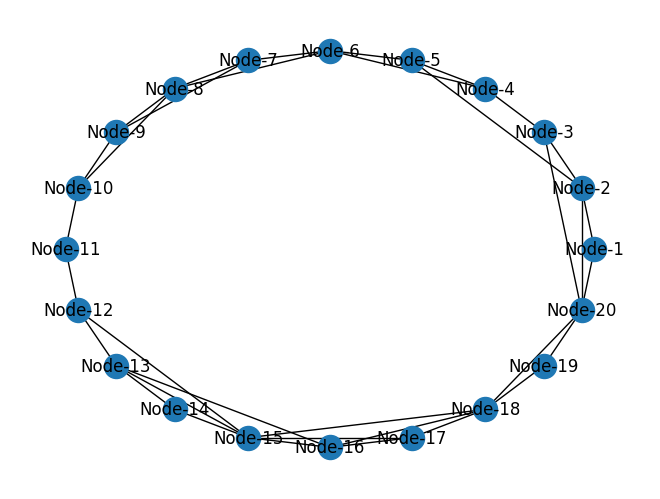

In [ ]:
nx.draw(g, get_positions_nx(rep), with_labels=True)
plt.show()

### Plotting the Tree Topology

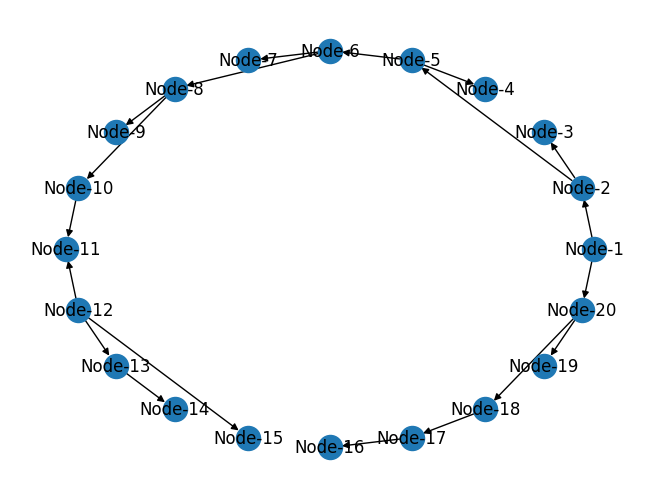

In [ ]:
nx.draw(t, get_positions_nx(rep), with_labels=True)
plt.show()